In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.knn import KNN
from utils.metrics_evaluator import MetricsEvaluator
from utils.helpers import min_max_normalization, to_percent

In [2]:
def drawHistogram(df: pd.DataFrame, col: str):
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribusi Data {col}')
    plt.show()

In [3]:
def drawBoxPlot(df: pd.DataFrame):
    plt.figure(figsize=(8, 6))
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df.boxplot()
    plt.title("Box Plot Setiap Fitur")
    plt.ylabel("Nilai")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()


    # plt.figure(figsize=(6, 4))
    # sns.boxplot(x=df[col].dropna())
    # plt.title(f'Boxplot Data {col}')
    # plt.show()

In [34]:
# dm2 anu murni dm2 hngkl
# dm2-all anu boga panyakit lain diasupken, tuluy direname
df = pd.read_csv("dataset-dm2.csv")
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,58.0,L,140.0,80.0,135.0,DM2
1,56.0,P,130.0,80.0,236.0,DM2
2,31.0,Perempuan,115.0,74.0,112.0,NDM
3,38.0,Perempuan,117.0,79.0,125.0,NDM
4,16.0,Perempuan,118.0,73.0,127.0,NDM
...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,NDM
802,56.0,P,120.0,80.0,152.0,DM2
803,32.0,P,120.0,80.0,122.0,DM2
804,28.0,Perempuan,115.0,77.0,134.0,NDM


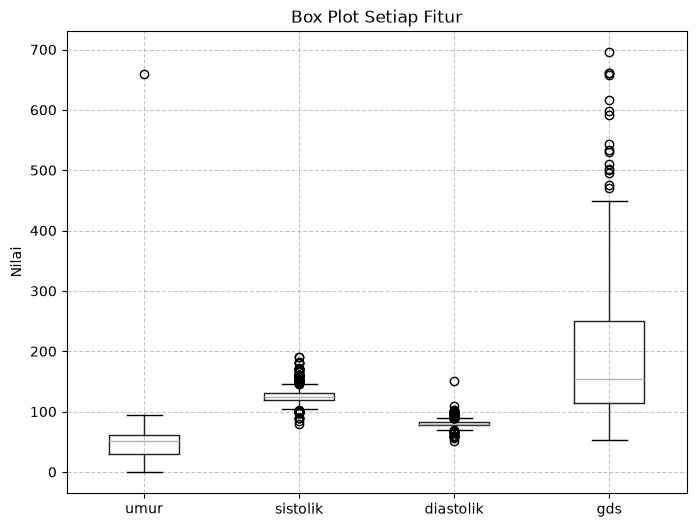

In [35]:
drawBoxPlot(df)

In [36]:
missingSistolikCount = df['sistolik'].isna().sum()
print(missingSistolikCount)

24


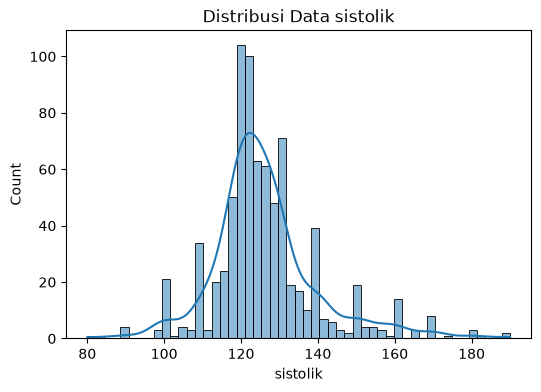

In [37]:
drawHistogram(df, 'sistolik')

In [38]:
# Filling missing 'sistolik' values with the mean
df['sistolik'] = df['sistolik'].fillna(df['sistolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,58.0,L,140.0,80.0,135.0,DM2
1,56.0,P,130.0,80.0,236.0,DM2
2,31.0,Perempuan,115.0,74.0,112.0,NDM
3,38.0,Perempuan,117.0,79.0,125.0,NDM
4,16.0,Perempuan,118.0,73.0,127.0,NDM
...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,NDM
802,56.0,P,120.0,80.0,152.0,DM2
803,32.0,P,120.0,80.0,122.0,DM2
804,28.0,Perempuan,115.0,77.0,134.0,NDM


In [39]:
missingDiastolikCount = df['diastolik'].isna().sum()
print(missingDiastolikCount)

24


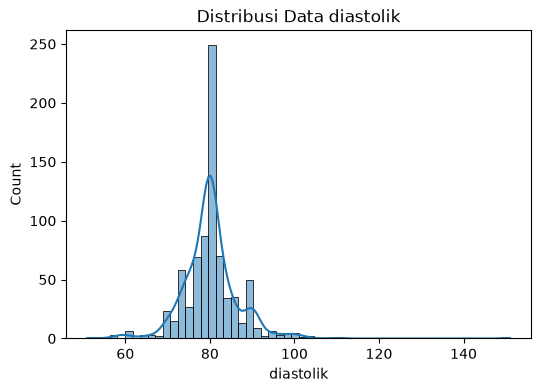

In [40]:
drawHistogram(df, 'diastolik')

In [41]:
# Mengisi nilai yang hilang pada kolom Diastolik dengan nilai rata-rata mean (nilai rata-rata)
df['diastolik'] = df['diastolik'].fillna(df['diastolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,58.0,L,140.0,80.0,135.0,DM2
1,56.0,P,130.0,80.0,236.0,DM2
2,31.0,Perempuan,115.0,74.0,112.0,NDM
3,38.0,Perempuan,117.0,79.0,125.0,NDM
4,16.0,Perempuan,118.0,73.0,127.0,NDM
...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,NDM
802,56.0,P,120.0,80.0,152.0,DM2
803,32.0,P,120.0,80.0,122.0,DM2
804,28.0,Perempuan,115.0,77.0,134.0,NDM


In [42]:
missingGdsCount = df['gds'].isna().sum()
print(missingGdsCount)

36


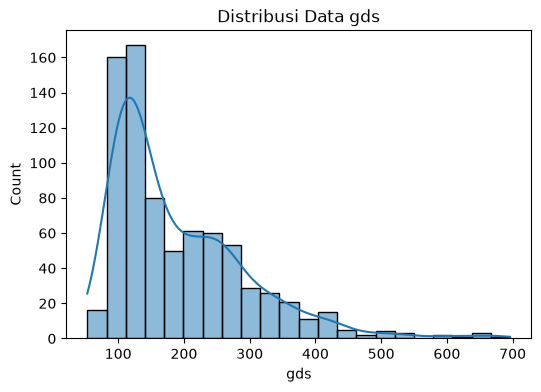

In [43]:
drawHistogram(df, 'gds')

In [44]:
# Mengisi nilai yang hilang pada kolom gds dengan nilai median (nilai tengah)
df['gds'] = df['gds'].fillna(df['gds'].median())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,58.0,L,140.0,80.0,135.0,DM2
1,56.0,P,130.0,80.0,236.0,DM2
2,31.0,Perempuan,115.0,74.0,112.0,NDM
3,38.0,Perempuan,117.0,79.0,125.0,NDM
4,16.0,Perempuan,118.0,73.0,127.0,NDM
...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,NDM
802,56.0,P,120.0,80.0,152.0,DM2
803,32.0,P,120.0,80.0,122.0,DM2
804,28.0,Perempuan,115.0,77.0,134.0,NDM


In [45]:
missingGenderCount = df['jenis_kelamin'].isna().sum()
print(missingGenderCount)

0


In [46]:
uniqueGenderValuesCount = df['jenis_kelamin'].nunique()
uniqueGenderValues = np.array(df['jenis_kelamin'].unique())

print(f"Jumlah nilai unik pada kolom 'jenis_kelamin': {uniqueGenderValuesCount}")
print(f"Nilai unik pada kolom 'jenis_kelamin': {uniqueGenderValues}")

Jumlah nilai unik pada kolom 'jenis_kelamin': 4
Nilai unik pada kolom 'jenis_kelamin': ['L' 'P' 'Perempuan' 'Laki-laki']


In [47]:
# Mengisi nilai yang hilang pada kolom jenis_kelamin dengan nilai modus (nilai yang sering mucul)
df['jenis_kelamin'] = df['jenis_kelamin'].fillna(df['jenis_kelamin'].mode()[0])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,58.0,L,140.0,80.0,135.0,DM2
1,56.0,P,130.0,80.0,236.0,DM2
2,31.0,Perempuan,115.0,74.0,112.0,NDM
3,38.0,Perempuan,117.0,79.0,125.0,NDM
4,16.0,Perempuan,118.0,73.0,127.0,NDM
...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,NDM
802,56.0,P,120.0,80.0,152.0,DM2
803,32.0,P,120.0,80.0,122.0,DM2
804,28.0,Perempuan,115.0,77.0,134.0,NDM


In [48]:
# Mapping Gender: P (Perempuan) to 1, L (Laki-laki) to 0
df['transformed_gender'] = df['jenis_kelamin'].map(lambda e: 1 if e == 'P' or e == 'Perempuan' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender
0,58.0,L,140.0,80.0,135.0,DM2,0
1,56.0,P,130.0,80.0,236.0,DM2,1
2,31.0,Perempuan,115.0,74.0,112.0,NDM,1
3,38.0,Perempuan,117.0,79.0,125.0,NDM,1
4,16.0,Perempuan,118.0,73.0,127.0,NDM,1
...,...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,NDM,1
802,56.0,P,120.0,80.0,152.0,DM2,1
803,32.0,P,120.0,80.0,122.0,DM2,1
804,28.0,Perempuan,115.0,77.0,134.0,NDM,1


In [49]:
missingYearCount = df['umur'].isna().sum()
print(missingYearCount)

1


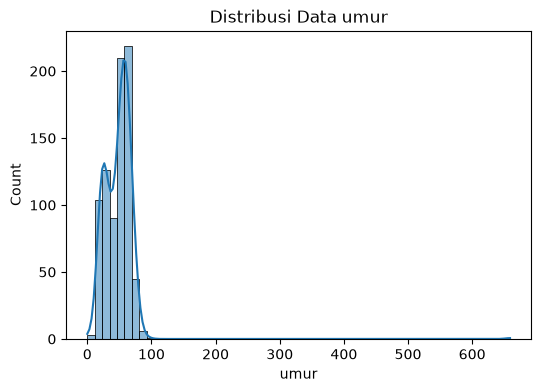

In [50]:
drawHistogram(df, 'umur')

In [51]:
# Mengisi nilai yang hilang pada kolom umur dengan nilai median (nilai tengah)
df['umur'] = df['umur'].fillna(df['umur'].median())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender
0,58.0,L,140.0,80.0,135.0,DM2,0
1,56.0,P,130.0,80.0,236.0,DM2,1
2,31.0,Perempuan,115.0,74.0,112.0,NDM,1
3,38.0,Perempuan,117.0,79.0,125.0,NDM,1
4,16.0,Perempuan,118.0,73.0,127.0,NDM,1
...,...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,NDM,1
802,56.0,P,120.0,80.0,152.0,DM2,1
803,32.0,P,120.0,80.0,122.0,DM2,1
804,28.0,Perempuan,115.0,77.0,134.0,NDM,1


In [52]:
uniqueDiagnoseValuesCount = df['diagnosa'].nunique()
uniqueDiagnoseValues = np.array(df['diagnosa'].unique())

print(f"Jumlah nilai unik pada kolom 'diagnosa': {uniqueDiagnoseValuesCount}")
print(f"Nilai unik pada kolom 'diagnosa': {uniqueDiagnoseValues}")

Jumlah nilai unik pada kolom 'diagnosa': 2
Nilai unik pada kolom 'diagnosa': ['DM2' 'NDM']


In [53]:
df['diagnosa'] = df['diagnosa'].map(lambda e: 1 if e == 'DM2' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender
0,58.0,L,140.0,80.0,135.0,1,0
1,56.0,P,130.0,80.0,236.0,1,1
2,31.0,Perempuan,115.0,74.0,112.0,0,1
3,38.0,Perempuan,117.0,79.0,125.0,0,1
4,16.0,Perempuan,118.0,73.0,127.0,0,1
...,...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,0,1
802,56.0,P,120.0,80.0,152.0,1,1
803,32.0,P,120.0,80.0,122.0,1,1
804,28.0,Perempuan,115.0,77.0,134.0,0,1


In [54]:
# Normalisasi kolom sistolik
df['norm_sistolik'] = min_max_normalization(df['sistolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik
0,58.0,L,140.0,80.0,135.0,1,0,0.545455
1,56.0,P,130.0,80.0,236.0,1,1,0.454545
2,31.0,Perempuan,115.0,74.0,112.0,0,1,0.318182
3,38.0,Perempuan,117.0,79.0,125.0,0,1,0.336364
4,16.0,Perempuan,118.0,73.0,127.0,0,1,0.345455
...,...,...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,0,1,0.327273
802,56.0,P,120.0,80.0,152.0,1,1,0.363636
803,32.0,P,120.0,80.0,122.0,1,1,0.363636
804,28.0,Perempuan,115.0,77.0,134.0,0,1,0.318182


In [55]:
# Normalisasi kolom diastolik
df['norm_diastolik'] = min_max_normalization(df['diastolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik
0,58.0,L,140.0,80.0,135.0,1,0,0.545455,0.29
1,56.0,P,130.0,80.0,236.0,1,1,0.454545,0.29
2,31.0,Perempuan,115.0,74.0,112.0,0,1,0.318182,0.23
3,38.0,Perempuan,117.0,79.0,125.0,0,1,0.336364,0.28
4,16.0,Perempuan,118.0,73.0,127.0,0,1,0.345455,0.22
...,...,...,...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,0,1,0.327273,0.24
802,56.0,P,120.0,80.0,152.0,1,1,0.363636,0.29
803,32.0,P,120.0,80.0,122.0,1,1,0.363636,0.29
804,28.0,Perempuan,115.0,77.0,134.0,0,1,0.318182,0.26


In [56]:
# Normalisasi kolom Umur
df['norm_umur'] = min_max_normalization(df['umur'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur
0,58.0,L,140.0,80.0,135.0,1,0,0.545455,0.29,0.088012
1,56.0,P,130.0,80.0,236.0,1,1,0.454545,0.29,0.084977
2,31.0,Perempuan,115.0,74.0,112.0,0,1,0.318182,0.23,0.047041
3,38.0,Perempuan,117.0,79.0,125.0,0,1,0.336364,0.28,0.057663
4,16.0,Perempuan,118.0,73.0,127.0,0,1,0.345455,0.22,0.024279
...,...,...,...,...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,0,1,0.327273,0.24,0.044006
802,56.0,P,120.0,80.0,152.0,1,1,0.363636,0.29,0.084977
803,32.0,P,120.0,80.0,122.0,1,1,0.363636,0.29,0.048558
804,28.0,Perempuan,115.0,77.0,134.0,0,1,0.318182,0.26,0.042489


In [57]:
# Normalisasi kolom gds (Gula Darah Sewaktu)
df['norm_gds'] = min_max_normalization(df['gds'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds
0,58.0,L,140.0,80.0,135.0,1,0,0.545455,0.29,0.088012,0.127527
1,56.0,P,130.0,80.0,236.0,1,1,0.454545,0.29,0.084977,0.284603
2,31.0,Perempuan,115.0,74.0,112.0,0,1,0.318182,0.23,0.047041,0.091757
3,38.0,Perempuan,117.0,79.0,125.0,0,1,0.336364,0.28,0.057663,0.111975
4,16.0,Perempuan,118.0,73.0,127.0,0,1,0.345455,0.22,0.024279,0.115086
...,...,...,...,...,...,...,...,...,...,...,...
801,29.0,Perempuan,116.0,75.0,77.0,0,1,0.327273,0.24,0.044006,0.037325
802,56.0,P,120.0,80.0,152.0,1,1,0.363636,0.29,0.084977,0.153966
803,32.0,P,120.0,80.0,122.0,1,1,0.363636,0.29,0.048558,0.107309
804,28.0,Perempuan,115.0,77.0,134.0,0,1,0.318182,0.26,0.042489,0.125972


newDf ini adalah cerminan dari dataset mentah yang sudah ditambahkan kolom transformasi dan normalisasi

In [58]:
newDf = df[['umur', 'sistolik', 'diastolik', 'gds', 'transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'diagnosa']]
newDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,58.0,140.0,80.0,135.0,0,0.545455,0.29,0.088012,0.127527,1
1,56.0,130.0,80.0,236.0,1,0.454545,0.29,0.084977,0.284603,1
2,31.0,115.0,74.0,112.0,1,0.318182,0.23,0.047041,0.091757,0
3,38.0,117.0,79.0,125.0,1,0.336364,0.28,0.057663,0.111975,0
4,16.0,118.0,73.0,127.0,1,0.345455,0.22,0.024279,0.115086,0
...,...,...,...,...,...,...,...,...,...,...
801,29.0,116.0,75.0,77.0,1,0.327273,0.24,0.044006,0.037325,0
802,56.0,120.0,80.0,152.0,1,0.363636,0.29,0.084977,0.153966,1
803,32.0,120.0,80.0,122.0,1,0.363636,0.29,0.048558,0.107309,1
804,28.0,115.0,77.0,134.0,1,0.318182,0.26,0.042489,0.125972,0


In [64]:
newDf.to_csv("dataset_preprocessed.csv", index=False)

# Evaluasi Dataset
Mulai dari membaca csv yang sudah diekspor

In [59]:
readyDf = pd.read_csv("dataset_preprocessed.csv")[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'diagnosa']]
readyDf

,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,0,0.545455,0.29,0.088012,0.127527,1
1,1,0.454545,0.29,0.084977,0.284603,1
2,1,0.318182,0.23,0.047041,0.091757,0
3,1,0.336364,0.28,0.057663,0.111975,0
4,1,0.345455,0.22,0.024279,0.115086,0
...,...,...,...,...,...,...
801,1,0.327273,0.24,0.044006,0.037325,0
802,1,0.363636,0.29,0.084977,0.153966,1
803,1,0.363636,0.29,0.048558,0.107309,1
804,1,0.318182,0.26,0.042489,0.125972,0


In [60]:
class DatasetEvaluator:
    def __init__(self, df: pd.DataFrame, training_size: float):
        self.df = df
        self.training_size = int(df.shape[0] * training_size)
    
    def split_datasets(self):
        # Memisahkan fitur (X) dan target (y)
        X = self.df[['norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'transformed_gender']]
        y = self.df['diagnosa']

        # Membagi dataset menjadi data Latih (Train) dan data Uji (Test)
        self.X_train = X.iloc[:self.training_size]
        self.y_train = y.iloc[:self.training_size]
        self.X_test = X.iloc[self.training_size:]
        self.y_test = y.iloc[self.training_size:]

        print("Dimensi data latih - {},{}".format(self.X_train.shape, self.y_train.shape))
        print("Dimensi data validasi - {},{}".format(self.X_test.shape, self.y_test.shape))
        
    def evaluate_knn(self):
        # Iterate through different K values and distance metrics to evaluate performance
        for k_count in np.array([3, 5, 7, 9]):
            knn = KNN(k=k_count)
            knn.fit(self.X_train, self.y_train)

            predictions = knn.predict(self.X_test.values)
            y_pred = predictions['Euclidean']
            
            # for distance_type, y_pred in predictions.items(): -> uncomment this if want to use all distance types
            evaluator = MetricsEvaluator(y_pred, self.y_test.values)
            evaluator.plot_confusion_matrix(title=f"Confusion Matrix - Jarak Euclidean (K={k_count})")
            accuracy = evaluator.accuracy()
            precision = evaluator.precision()
            recall = evaluator.recall()
            f1_score = evaluator.f1_score()

            print(f"Results for Euclidean Distance (K={k_count})")
            print(f"Accuracy: {to_percent(accuracy)}, Precision: {to_percent(precision)}, Recall: {to_percent(recall)}, F1-Score: {to_percent(f1_score)}")
            print("-" * 80)

# Pembagian Data
Membagi dataset dengan komposisi train:test dengan beberapa skenario, di antaranya 80:20, 75:25, 90:10

# 80:20

In [74]:
datasetEighty = DatasetEvaluator(readyDf, training_size=0.8)
datasetEighty.split_datasets()
datasetEighty.evaluate_knn()

Dimensi data latih - (644, 5),(644,)
Dimensi data validasi - (162, 5),(162,)
Results for Euclidean Distance (K=3)
Accuracy: 85.80%, Precision: 84.93%, Recall: 83.78%, F1-Score: 84.35%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 82.72%, Precision: 80.26%, Recall: 82.43%, F1-Score: 81.33%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 83.95%, Precision: 81.58%, Recall: 83.78%, F1-Score: 82.67%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 83.33%, Precision: 80.52%, Recall: 83.78%, F1-Score: 82.12%
--------------------------------------------------------------------------------


# 75:25

In [70]:
datasetSeventyFive = DatasetEvaluator(readyDf, training_size=0.75)
datasetSeventyFive.split_datasets()
datasetSeventyFive.evaluate_knn()

Dimensi data latih - (604, 5),(604,)
Dimensi data validasi - (202, 5),(202,)
Results for Euclidean Distance (K=3)
Accuracy: 83.66%, Precision: 81.11%, Recall: 82.02%, F1-Score: 81.56%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 82.67%, Precision: 78.72%, Recall: 83.15%, F1-Score: 80.87%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 83.66%, Precision: 79.17%, Recall: 85.39%, F1-Score: 82.16%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 80.69%, Precision: 75.00%, Recall: 84.27%, F1-Score: 79.37%
--------------------------------------------------------------------------------


# 90:10

In [71]:
datasetNinety = DatasetEvaluator(readyDf, training_size=0.9)
datasetNinety.split_datasets()
datasetNinety.evaluate_knn()

Dimensi data latih - (725, 5),(725,)
Dimensi data validasi - (81, 5),(81,)
Results for Euclidean Distance (K=3)
Accuracy: 87.65%, Precision: 85.71%, Recall: 85.71%, F1-Score: 85.71%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 83.95%, Precision: 78.95%, Recall: 85.71%, F1-Score: 82.19%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 85.19%, Precision: 81.08%, Recall: 85.71%, F1-Score: 83.33%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 83.95%, Precision: 78.95%, Recall: 85.71%, F1-Score: 82.19%
--------------------------------------------------------------------------------


# K-Fold Cross Validation => K = 4, 5, 10

In [61]:
K = np.array([4, 5, 10])

In [62]:
kFoldDf = pd.read_csv("dataset_preprocessed.csv")[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'diagnosa']]
kFoldDf

,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,0,0.545455,0.29,0.088012,0.127527,1
1,1,0.454545,0.29,0.084977,0.284603,1
2,1,0.318182,0.23,0.047041,0.091757,0
3,1,0.336364,0.28,0.057663,0.111975,0
4,1,0.345455,0.22,0.024279,0.115086,0
...,...,...,...,...,...,...
801,1,0.327273,0.24,0.044006,0.037325,0
802,1,0.363636,0.29,0.084977,0.153966,1
803,1,0.363636,0.29,0.048558,0.107309,1
804,1,0.318182,0.26,0.042489,0.125972,0


In [63]:
X = kFoldDf[['norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'transformed_gender']]
y = kFoldDf['diagnosa']

In [ ]:
from sklearn.model_selection import StratifiedKFold

results_storage = []

for k_count in K:
    # Buat objek Stratified K-Fold
    skf = StratifiedKFold(n_splits=k_count, shuffle=True, random_state=42)
    
    for fold_index, (train_idx, test_idx) in enumerate(list(skf.split(X,y))):
        k_X_train, k_X_test = X.iloc[train_idx], X.iloc[test_idx]
        k_y_train, k_y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        for k_knn in np.array([3, 5, 7, 9]):
            print(f"Fold {fold_index + 1}/{k_count} - K={k_knn}")
            knn = KNN(k=k_knn)
            knn.fit(k_X_train, k_y_train)

            predictions = knn.predict(k_X_test.values)
            y_pred = predictions['Euclidean']
            
            evaluator = MetricsEvaluator(y_pred, k_y_test.values)
            figure = evaluator.plot_confusion_matrix(
                title=f"Confusion Matrix - Jarak Euclidean (K={k_knn}) - Fold {fold_index + 1}/{k_count}"
            )
            
            results_storage.append({
                'K_Fold': k_count,
                'Figure': figure,
                'Fold': fold_index + 1,
                'K_KNN': k_knn,
                'Distance': 'Euclidean',
                'Accuracy': evaluator.accuracy(),
                'Precision': evaluator.precision(),
                'Recall': evaluator.recall(),
                'F1_Score': evaluator.f1_score()
            })

Fold 1/4 - K=3
Fold 1/4 - K=5
Fold 1/4 - K=7
Fold 1/4 - K=9
Fold 2/4 - K=3
Fold 2/4 - K=5
Fold 2/4 - K=7
Fold 2/4 - K=9
Fold 3/4 - K=3
Fold 3/4 - K=5
Fold 3/4 - K=7
Fold 3/4 - K=9
Fold 4/4 - K=3
Fold 4/4 - K=5
Fold 4/4 - K=7
Fold 4/4 - K=9
Fold 1/5 - K=3
Fold 1/5 - K=5
Fold 1/5 - K=7
Fold 1/5 - K=9
Fold 2/5 - K=3
Fold 2/5 - K=5
Fold 2/5 - K=7
Fold 2/5 - K=9
Fold 3/5 - K=3
Fold 3/5 - K=5
Fold 3/5 - K=7
Fold 3/5 - K=9
Fold 4/5 - K=3
Fold 4/5 - K=5
Fold 4/5 - K=7
Fold 4/5 - K=9
Fold 5/5 - K=3
Fold 5/5 - K=5
Fold 5/5 - K=7
Fold 5/5 - K=9
Fold 1/10 - K=3
Fold 1/10 - K=5
Fold 1/10 - K=7
Fold 1/10 - K=9
Fold 2/10 - K=3
Fold 2/10 - K=5
Fold 2/10 - K=7
Fold 2/10 - K=9
Fold 3/10 - K=3
Fold 3/10 - K=5
Fold 3/10 - K=7
Fold 3/10 - K=9
Fold 4/10 - K=3
Fold 4/10 - K=5
Fold 4/10 - K=7
Fold 4/10 - K=9
Fold 5/10 - K=3
Fold 5/10 - K=5
Fold 5/10 - K=7
Fold 5/10 - K=9
Fold 6/10 - K=3
Fold 6/10 - K=5
Fold 6/10 - K=7
Fold 6/10 - K=9
Fold 7/10 - K=3
Fold 7/10 - K=5
Fold 7/10 - K=7
Fold 7/10 - K=9
Fold 8/10 - 

In [65]:
df_results = pd.DataFrame(results_storage).drop(columns=['Figure'])
df_results

,K_Fold,Fold,K_KNN,Distance,Accuracy,Precision,Recall,F1_Score
0,4,1,3,Euclidean,0.797030,0.778846,0.818182,0.798030
1,4,1,5,Euclidean,0.801980,0.770642,0.848485,0.807692
2,4,1,7,Euclidean,0.777228,0.754717,0.808081,0.780488
3,4,1,9,Euclidean,0.792079,0.771429,0.818182,0.794118
4,4,2,3,Euclidean,0.841584,0.823529,0.857143,0.840000
...,...,...,...,...,...,...,...,...
71,10,9,9,Euclidean,0.825000,0.837838,0.794872,0.815789
72,10,10,3,Euclidean,0.875000,0.853659,0.897436,0.875000
73,10,10,5,Euclidean,0.875000,0.914286,0.820513,0.864865
74,10,10,7,Euclidean,0.850000,0.885714,0.794872,0.837838


In [69]:
sorted_df_results = df_results.sort_values(by=['Accuracy'], ascending=False).reset_index(drop=True)
sorted_df_results

,K_Fold,Fold,K_KNN,Distance,Accuracy,Precision,Recall,F1_Score
0,10,5,9,Euclidean,0.888889,0.875000,0.897436,0.886076
1,10,5,3,Euclidean,0.888889,0.875000,0.897436,0.886076
2,10,5,7,Euclidean,0.876543,0.871795,0.871795,0.871795
3,10,5,5,Euclidean,0.876543,0.871795,0.871795,0.871795
4,10,10,5,Euclidean,0.875000,0.914286,0.820513,0.864865
...,...,...,...,...,...,...,...,...
71,5,1,7,Euclidean,0.753086,0.714286,0.822785,0.764706
72,10,6,7,Euclidean,0.753086,0.771429,0.692308,0.729730
73,10,8,7,Euclidean,0.750000,0.787879,0.666667,0.722222
74,10,2,5,Euclidean,0.740741,0.711111,0.800000,0.752941


In [89]:
best_configs = sorted_df_results.iloc[0][['K_Fold', 'Fold', 'K_KNN']]
best_configs

K_Fold    10
Fold       5
K_KNN      9
Name: 0, dtype: object

Fold 5/10 - K=9


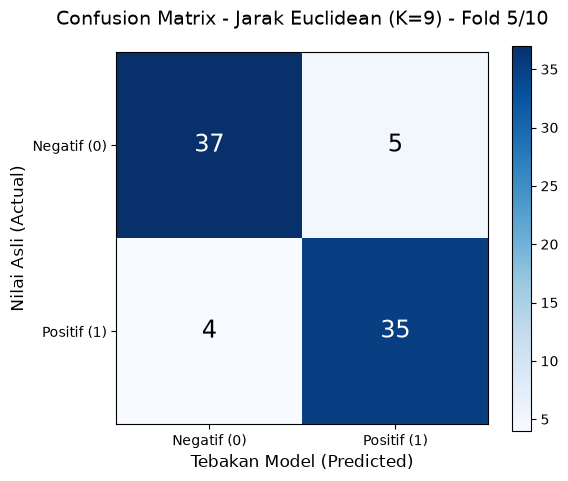

In [98]:
import joblib

skf = StratifiedKFold(n_splits=k_count, shuffle=True, random_state=42)

for k_count in np.array([best_configs['K_Fold']]): # K-Fold Cross Validation
    for fold_index, (train_idx, test_idx) in enumerate(list(skf.split(X,y))):
        if(fold_index != best_configs['Fold'] - 1): continue # nth Fold, -1 because index starts from 0
        
        best_X_train, best_X_test = X.iloc[train_idx], X.iloc[test_idx]
        best_y_train, best_y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        for k_knn in np.array([best_configs['K_KNN']]): # K KNN
            print(f"Fold {fold_index + 1}/{k_count} - K={k_knn}")
            knn = KNN(k=k_knn)
            knn.fit(best_X_train, best_y_train)
            joblib.dump(knn, "best_knn_model.joblib")

            predictions = knn.predict(best_X_test.values)
            best_y_pred = predictions['Euclidean']
            
            evaluator = MetricsEvaluator(best_y_pred, best_y_test.values)
            figure = evaluator.plot_confusion_matrix(
                title=f"Confusion Matrix - Jarak Euclidean (K={k_knn}) - Fold {fold_index + 1}/{k_count}"
            )
            display(figure)

In [93]:
summary_results = df_results.groupby(['K_Fold', 'K_KNN'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].agg(['mean']).reset_index()
summary_results.columns = ['_'.join(col).strip('_') for col in summary_results.columns.values]
summary_results

,K_Fold,K_KNN,Accuracy_mean,Precision_mean,Recall_mean,F1_Score_mean
0,4,3,0.821345,0.819540,0.814239,0.816341
1,4,5,0.818870,0.818376,0.811611,0.813755
2,4,7,0.807694,0.806690,0.798959,0.802077
3,4,9,0.812632,0.807889,0.809137,0.807473
4,5,3,0.823894,0.823614,0.816715,0.819249
5,5,5,0.813964,0.810761,0.811490,0.809841
6,5,7,0.801549,0.801597,0.793768,0.796431
7,5,9,0.801534,0.805100,0.786141,0.794568
8,10,3,0.828873,0.827485,0.824679,0.823957
9,10,5,0.818935,0.819801,0.814359,0.814556


In [94]:
sorted_kfold = summary_results.sort_values(by='Accuracy_mean', ascending=False)

print(f"K-Fold      : {sorted_kfold.iloc[0]['K_Fold']}")
print(f"K-KNN       : {sorted_kfold.iloc[0]['K_KNN']}")
print(f"Accuracy    : {to_percent(sorted_kfold.iloc[0]['Accuracy_mean'])}")
print(f"Precision   : {to_percent(sorted_kfold.iloc[0]['Precision_mean'])}")
print(f"Recall      : {to_percent(sorted_kfold.iloc[0]['Recall_mean'])}")
print(f"F1-Score    : {to_percent(sorted_kfold.iloc[0]['F1_Score_mean'])}")

K-Fold      : 10.0
K-KNN       : 3.0
Accuracy    : 82.89%
Precision   : 82.75%
Recall      : 82.47%
F1-Score    : 82.40%


In [95]:
# Grouping berdasarkan K_Fold dan K_KNN, lalu hitung rata-rata dari semua fold untuk setiap kombinasi K_Fold dan K_KNN
df_avg_double_k = df_results.groupby(['K_Fold', 'K_KNN'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean().reset_index()
df_avg_double_k

,K_Fold,K_KNN,Accuracy,Precision,Recall,F1_Score
0,4,3,0.821345,0.819540,0.814239,0.816341
1,4,5,0.818870,0.818376,0.811611,0.813755
2,4,7,0.807694,0.806690,0.798959,0.802077
3,4,9,0.812632,0.807889,0.809137,0.807473
4,5,3,0.823894,0.823614,0.816715,0.819249
5,5,5,0.813964,0.810761,0.811490,0.809841
6,5,7,0.801549,0.801597,0.793768,0.796431
7,5,9,0.801534,0.805100,0.786141,0.794568
8,10,3,0.828873,0.827485,0.824679,0.823957
9,10,5,0.818935,0.819801,0.814359,0.814556
